# Teste de conhecimento 1 - matemática aplicada
**Análise e previsão dos custos mensais de transporte (função afim)**

**Aluno:** Yehoshua vieira
**Disciplina:** Matemática Aplicada à Computação

## Contextualização
Uma empresa de comércio eletrônico acompanha seus custos mensais de transporte. Vamos analisar como esses custos variam ao longo de 12 meses, encontrar uma função afim $f(x) = ax + b$ que os represente e usá-la para prever os próximos três meses.

## Etapa 1 – Carregar os dados

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# No Google Colab: envie o arquivo base_custos_transporte.csv pelo painel de arquivos (ícone de pasta à esquerda)
# ou execute a linha abaixo para abrir a janela de upload.
import os
if not os.path.exists('base_custos_transporte.csv'):
    from google.colab import files
    files.upload()

df = pd.read_csv('base_custos_transporte.csv')
df

,mes,custo_transporte
0,1,44500
1,2,45200
2,3,48300
3,4,48600
4,5,51300
5,6,53300
6,7,53800
7,8,57000
8,9,57900
9,10,61000


## Etapa 2 – Identificar as variáveis

**a) Variável independente:** `mes` (número do mês).

**b) Variável dependente:** `custo_transporte` (custo total de transporte no mês, em reais).

**c) O que cada uma representa:**
- `mes` (x): o tempo, em meses, contado de 1 a 12. É a variável que "escolhemos" para observar; o custo é analisado em função dela.
- `custo_transporte` (y): o valor total gasto com transporte naquele mês, em R$. Seu valor **depende** do mês, ou seja, y = f(x).

## Etapa 3 – Gráfico de dispersão

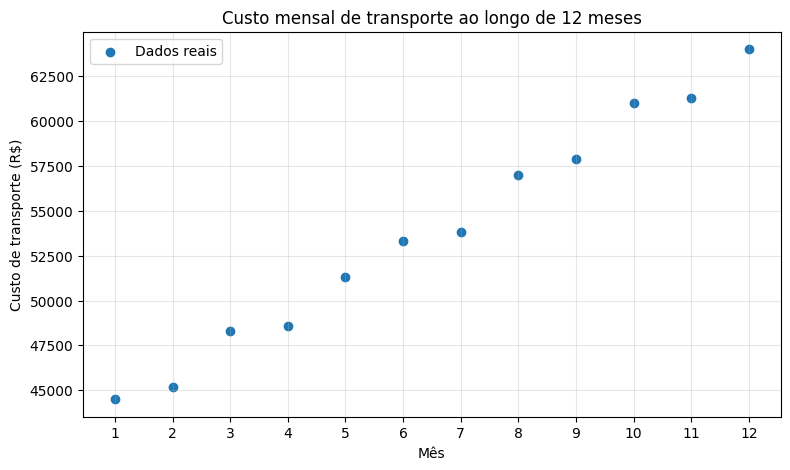

In [20]:
x = df['mes'].to_numpy()
y = df['custo_transporte'].to_numpy()

plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='tab:blue', label='Dados reais')
plt.title('Custo mensal de transporte ao longo de 12 meses')
plt.xlabel('Mês')
plt.ylabel('Custo de transporte (R$)')
plt.xticks(x)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Comportamento observado:** os pontos seguem uma trajetória crescente e aproximadamente alinhada. O custo sobe de RS 44.500 (mês 1) para RS 64.000 (mês 12), com pequenas oscilações de um mês para outro, mas sem quedas. Isso sugere que uma função afim (reta) é um bom modelo.

## Etapa 4 – Encontrar uma função afim

Usamos o **método dos mínimos quadrados** (reta que minimiza a soma dos quadrados dos erros), com as fórmulas para $n$ pontos:

$$a = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad b = \bar{y} - a\,\bar{x}$$

em que $\bar{x}$ e $\bar{y}$ são as médias de x e y.

In [21]:
n = len(x)
x_med = x.sum() / n
y_med = y.sum() / n

numerador = ((x - x_med) * (y - y_med)).sum()
denominador = ((x - x_med) ** 2).sum()

a = numerador / denominador
b = y_med - a * x_med

print(f'Média de x: {x_med:.2f}')
print(f'Média de y: R$ {y_med:,.2f}')
print(f'Numerador (Σ(x-x̄)(y-ȳ)): {numerador:,.2f}')
print(f'Denominador (Σ(x-x̄)²): {denominador:,.2f}')
print()
print(f'a = {numerador:,.2f} / {denominador:,.2f} = {a:.4f}')
print(f'b = {y_med:,.2f} - {a:.4f} × {x_med:.2f} = {b:.4f}')
print()
print(f'Função encontrada: f(x) = {a:.2f}x + {b:.2f}')

Média de x: 6.50
Média de y: R$ 53,850.00
Numerador (Σ(x-x̄)(y-ȳ)): 256,200.00
Denominador (Σ(x-x̄)²): 143.00

a = 256,200.00 / 143.00 = 1791.6084
b = 53,850.00 - 1791.6084 × 6.50 = 42204.5455

Função encontrada: f(x) = 1791.61x + 42204.55


**Resultado:**
- $a \approx 1.791{,}61$
- $b \approx 42.204{,}55$
- **Função:** $f(x) = 1791{,}61\,x + 42204{,}55$

## Etapa 5 – Interpretar a função

**a) Coeficiente a:** é a taxa de variação (inclinação da reta). Indica que, em média, o custo de transporte varia cerca de **R$ 1.791,61 a cada mês**.

**b) Coeficiente b:** é o valor da função quando x = 0, ou seja, o custo estimado "no mês 0" (ponto de partida do modelo), cerca de **R$ 42.204,55**. É o ponto onde a reta cruza o eixo y.

**c)** Como $a > 0$, indica **crescimento** dos custos.

## Etapa 6 – Representar a função no gráfico

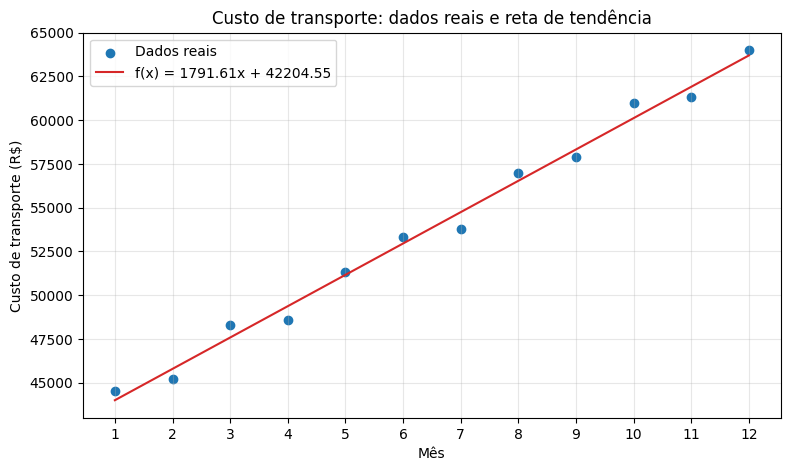

In [22]:
def f(x):
    return a * x + b

x_reta = np.linspace(1, 12, 100)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='tab:blue', label='Dados reais')
plt.plot(x_reta, f(x_reta), color='tab:red', label=f'f(x) = {a:.2f}x + {b:.2f}')
plt.title('Custo de transporte: dados reais e reta de tendência')
plt.xlabel('Mês')
plt.ylabel('Custo de transporte (R$)')
plt.xticks(x)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

A reta passa muito próxima dos pontos e mostra claramente a tendência de alta dos custos ao longo do tempo.

## Etapa 7 – Previsões (meses 13, 14 e 15)

Substituindo em $f(x) = ax + b$:

In [23]:
for mes in [13, 14, 15]:
    custo = f(mes)
    print(f'Mês {mes}: f({mes}) = {a:.4f} × {mes} + {b:.4f} = R$ {custo:,.2f}')

Mês 13: f(13) = 1791.6084 × 13 + 42204.5455 = R$ 65,495.45
Mês 14: f(14) = 1791.6084 × 14 + 42204.5455 = R$ 67,287.06
Mês 15: f(15) = 1791.6084 × 15 + 42204.5455 = R$ 69,078.67


**Previsões (valores aproximados):**
- Mês 13: RS 65.495,45
- Mês 14: RS 67.287,06
- Mês 15: RS 69.078,67

## Etapa 8 – Analisar o resultado

In [24]:
df['custo_previsto'] = f(df['mes'])
df['erro'] = df['custo_transporte'] - df['custo_previsto']
print(df.round(2).to_string(index=False))

# Coeficiente de determinação R² (quanto maior, melhor o ajuste; máximo = 1)
ss_res = (df['erro'] ** 2).sum()
ss_tot = ((y - y_med) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f'\nR² = {r2:.4f}')

 mes  custo_transporte  custo_previsto    erro
   1             44500        43996.15  503.85
   2             45200        45787.76 -587.76
   3             48300        47579.37  720.63
   4             48600        49370.98 -770.98
   5             51300        51162.59  137.41
   6             53300        52954.20  345.80
   7             53800        54745.80 -945.80
   8             57000        56537.41  462.59
   9             57900        58329.02 -429.02
  10             61000        60120.63  879.37
  11             61300        61912.24 -612.24
  12             64000        63703.85  296.15

R² = 0.9905


**a) A função representa bem a tendência?** Sim. O erro em cada mês é pequeno (sempre abaixo de RS 1.000 em módulo, frente a custos entre RS 44 mil e RS 64 mil) e o $R^2 \approx 0{,}99$ indica que a reta explica cerca de 99% da variação dos custos.

**b) Os custos estão aumentando ou diminuindo?** Estão **aumentando**, de forma praticamente constante.

**c) Quanto aumenta por mês?** Aproximadamente **RS 1.791,61 por mês** (o valor de a).

## Etapa 9 – Conclusão

Os dados dos 12 meses mostram uma tendência clara e quase linear de aumento nos custos de transporte, bem descrita pela função $f(x) = 1791{,}61x + 42204{,}55$ ($R^2 \approx 0{,}99$). Mantido esse comportamento, a empresa pode esperar custos de cerca de **RS 65,5 mil no mês 13, RS 67,3 mil no mês 14 e RS 69,1 mil no mês 15**, ou seja, um acréscimo de aproximadamente RS 1,8 mil a cada mês.

Vale lembrar que se trata de uma previsão baseada apenas no histórico: fatores como sazonalidade, reajuste de frete ou mudança no volume de vendas podem alterar a tendência, por isso o modelo deve ser revisado com novos dados.